In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset with low_memory=False to handle mixed types
df = pd.read_csv('../data/AI_movies_dataset.csv', low_memory=False)

# 2. Function to parse JSON-like columns
def parse_json_column(column_data, key_name='name'):
    try:
        # Convert string representation of list to actual list
        items = ast.literal_eval(column_data)
        if isinstance(items, list):
            return ", ".join([i[key_name] for i in items if key_name in i])
        return "Unknown"
    except (ValueError, SyntaxError, TypeError):
        return "Unknown"

# Clean JSON-like columns
json_cols = ['genres', 'production_companies', 'production_countries', 'spoken_languages']
for col in json_cols:
    print(f"Processing JSON structure in: {col}")
    df[col] = df[col].apply(lambda x: parse_json_column(x) if pd.notnull(x) else "Unknown")

# 3. Data Cleaning: Robust Type Conversion
# Convert problematic columns to numeric, forcing errors to NaN
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

# 4. Handling Missing Values

df = df.dropna(subset=['title']) # --> droping rows of title with null values
df['tagline'] = df['tagline'].fillna(' ') # --> placing blank space in place of null values in tagline

# Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with 'Unknown'
# object_cols = df.select_dtypes(include=['object']).columns
# for col in object_cols:
#     df[col] = df[col].fillna("Unknown")

# Remove duplicates
df.drop_duplicates(inplace=True)

df.drop(columns = ["homepage","imdb_id","original_language","original_title","poster_path","video"],inplace = True)


# 5. Statistical Overview
print("\nCleaned Dataset Shape:", df.shape)
display(df)
display(df.info())



Processing JSON structure in: genres
Processing JSON structure in: production_companies
Processing JSON structure in: production_countries
Processing JSON structure in: spoken_languages

Cleaned Dataset Shape: (45443, 18)


,adult,belongs_to_collection,budget,genres,id,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000.0,"Animation, Comedy, Family",862,"Led by Woody, Andy's toys live happily in his ...",21.946943,Pixar Animation Studios,United States of America,1995-10-30,373554033.0,81.0,English,Released,,Toy Story,7.7,5415.0
1,False,NaN,65000000.0,"Adventure, Fantasy, Family",8844,When siblings Judy and Peter discover an encha...,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,1995-12-15,262797249.0,104.0,"English, Français",Released,Roll the dice and unleash the excitement!,Jumanji,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0.0,"Romance, Comedy",15602,A family wedding reignites the ancient feud be...,11.712900,"Warner Bros., Lancaster Gate",United States of America,1995-12-22,0.0,101.0,English,Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,6.5,92.0
3,False,NaN,16000000.0,"Comedy, Drama, Romance",31357,"Cheated on, mistreated and stepped on, the wom...",3.859495,Twentieth Century Fox Film Corporation,United States of America,1995-12-22,81452156.0,127.0,English,Released,Friends are the people who let you be yourself...,Waiting to Exhale,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0.0,Comedy,11862,Just when George Banks has recovered from his ...,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,1995-02-10,76578911.0,106.0,English,Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45461,False,NaN,0.0,"Drama, Family",439050,Rising and falling between a man and woman.,0.072051,,Iran,NaN,0.0,90.0,فارسی,Released,Rising and falling between a man and woman,Subdue,4.0,1.0
45462,False,NaN,0.0,Drama,111109,An artist struggles to finish his work while a...,0.178241,Sine Olivia,Philippines,2011-11-17,0.0,360.0,,Released,,Century of Birthing,9.0,3.0
45463,False,NaN,0.0,"Action, Drama, Thriller",67758,"When one of her hits goes wrong, a professiona...",0.903007,American World Pictures,United States of America,2003-08-01,0.0,90.0,English,Released,A deadly game of wits.,Betrayal,3.8,6.0
45464,False,NaN,0.0,,227506,"In a small town live two brothers, one a minis...",0.003503,Yermoliev,Russia,1917-10-21,0.0,87.0,,Released,,Satan Triumphant,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 45443 entries, 0 to 45465
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45443 non-null  object 
 1   belongs_to_collection  4489 non-null   object 
 2   budget                 45443 non-null  float64
 3   genres                 45443 non-null  object 
 4   id                     45443 non-null  object 
 5   overview               44489 non-null  object 
 6   popularity             45443 non-null  float64
 7   production_companies   45443 non-null  object 
 8   production_countries   45443 non-null  object 
 9   release_date           45359 non-null  object 
 10  revenue                45443 non-null  float64
 11  runtime                45443 non-null  float64
 12  spoken_languages       45443 non-null  object 
 13  status                 45362 non-null  object 
 14  tagline                45443 non-null  object 
 15  title  

None

In [ ]:
import ast

# Function to safely extract the collection name
def fetch_collection(text):
    if pd.isna(text):
        return " "
    try:
        # The data is stored as a stringified dictionary
        return ast.literal_eval(text)['name']
    except:
        return " "

# 1. Create a new collection column
df['collection'] = df['belongs_to_collection'].apply(fetch_collection)

# 2. Update your tags creation to INCLUDE the collection!
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline'] + " " + df['collection'] + df['production_companies'] + df["production_countries"]

In [ ]:
df.drop(columns = ["belongs_to_collection"],inplace=True)

In [ ]:
# **NATURAL LANGUAGE PROCESSING**




import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
  text = str(text).lower() # --> lowercase
  text = re.sub(r'[^a-zA-Z\s]', '',text) # --> removed the punctuations

  words = text.split()

  # remove stopwords
  words = [word for word in words if word not in stop_words]

  #lemmatize
  words = [lemmatizer.lemmatize(word) for word in words]

  return " ".join(words) # --> list to string conversion
df['tags'] = df['tags'].apply(preprocess_text)
df.head()
df = df.reset_index(drop = True)
df
indices = pd.Series(df.index, index = df['title']).drop_duplicates() # creating series for indices with movies
indices
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range= (1,2), max_features = 50000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['tags'])
tfidf_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1557521 stored elements and shape (45443, 50000)>

In [ ]:
# **Cosine Similarities**
from sklearn.metrics.pairwise import cosine_similarity
def recommend(title, n=10):
  if title not in indices:
    return ['Movie not found']

  idx = indices[title]
  sim_score = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
  similar_idx = sim_score.argsort()[::-1][1:n+1]
  return df['title'].iloc[similar_idx]
recommend('Avatar')



import pickle

pickle.dump(tfidf_matrix,open('models/tfidf_matrix.pkl', 'wb'))

pickle.dump(indices,open('models/indices.pkl', 'wb'))

df.to_pickle('models/df.pkl')

pickle.dump(tfidf, open('models/tfidf.pkl', 'wb'))

,title
26547,Avatar 2
43428,Moontrap: Target Earth
13883,The Inhabited Island
26553,Thor: Ragnarok
7472,Frank Herbert's Dune
6414,Lara Croft Tomb Raider: The Cradle of Life
9949,A Trip to the Moon
16331,On the Silver Globe
29976,Shakedown
20593,Stray Dog: Kerberos Panzer Cops


# 2


Data is now cleaned with expanded JSON features.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45443 entries, 0 to 45442
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45443 non-null  object 
 1   budget                45443 non-null  float64
 2   genres                45443 non-null  object 
 3   popularity            45443 non-null  float64
 4   production_companies  45443 non-null  object 
 5   production_countries  45443 non-null  object 
 6   release_date          45359 non-null  object 
 7   revenue               45443 non-null  float64
 8   runtime               45443 non-null  float64
 9   spoken_languages      45443 non-null  object 
 10  status                45362 non-null  object 
 11  title                 45443 non-null  object 
 12  vote_average          45443 non-null  float64
 13  vote_count            45443 non-null  float64
 14  collection          

,budget,popularity,revenue,runtime,vote_average,vote_count
count,4.544300e+04,45443.000000,4.544300e+04,45443.000000,45443.000000,45443.000000
mean,4.226417e+06,2.921510,1.121350e+07,94.131175,5.618311,109.922210
std,1.742775e+07,6.006106,6.434392e+07,38.303744,1.924092,491.398368
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,0.386012,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,1.127613,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,3.679023,0.000000e+00,107.000000,6.800000,34.000000
max,3.800000e+08,547.488298,2.787965e+09,1256.000000,10.000000,14075.000000


/tmp/ipykernel_6375/2025428663.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


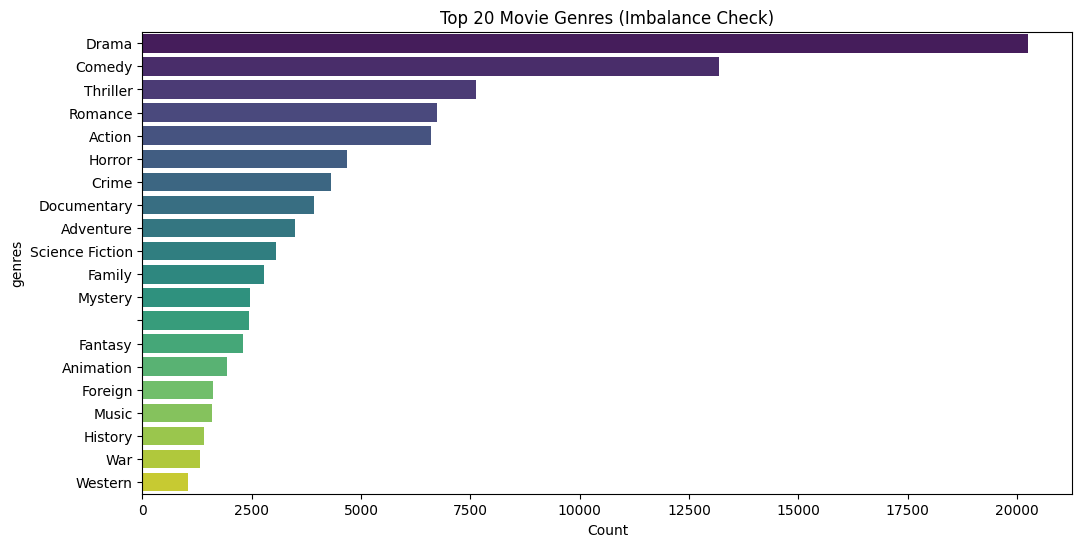

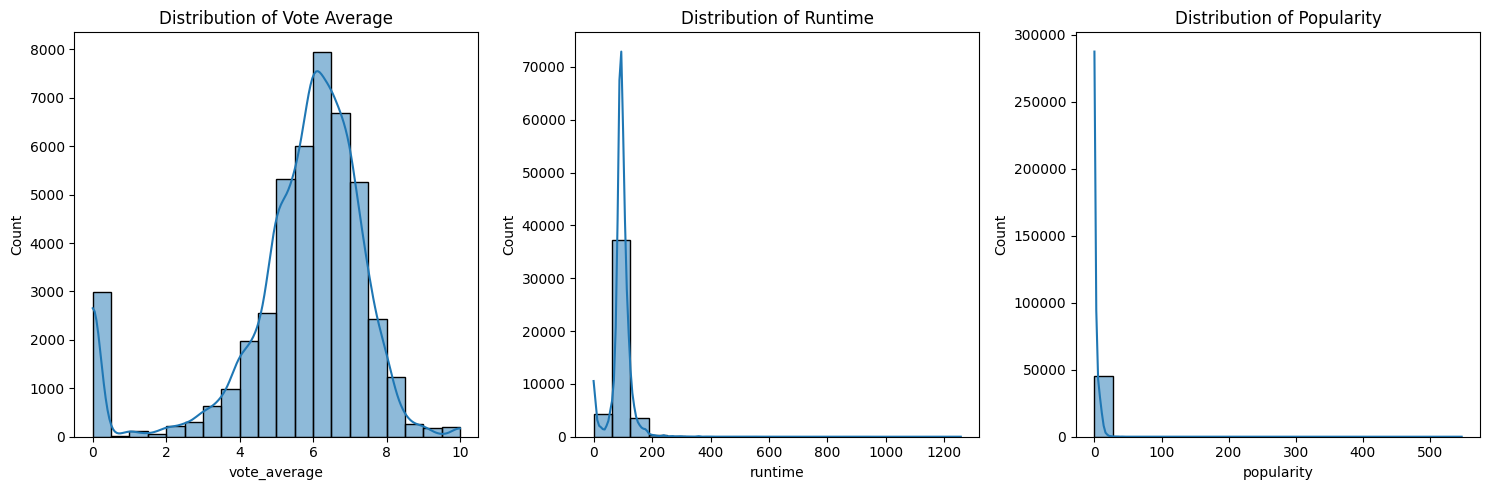

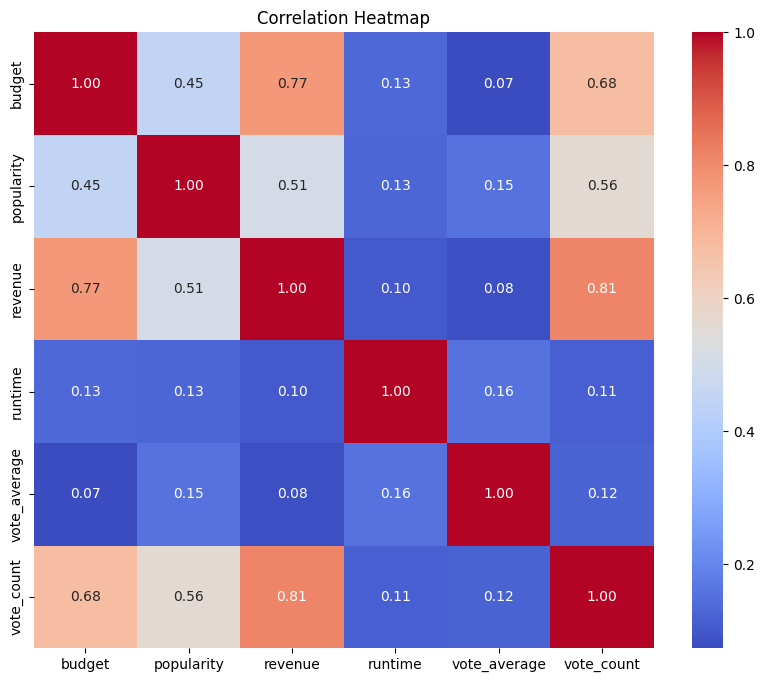

Statistical analysis complete. You can see the distributions and potential feature correlations above.


In [ ]:
# 6. Feature Selection (Simplified for cleaned structure)
# Dropping columns that are usually too unique for general ML (IDs, paths, etc.)


df_ml = df[['title', 'budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']].copy()
print("\nData is now cleaned with expanded JSON features.")
df_ml.info()



# Drop rows where title is missing
df_ml = df_ml.dropna(subset=['title'])

# Fill missing numerical values with mean or 0
df_ml['runtime'] = df_ml['runtime'].fillna(df_ml['runtime'].mean())
df_ml['vote_average'] = df_ml['vote_average'].fillna(df_ml['vote_average'].mean())
df_ml['vote_count'] = df_ml['vote_count'].fillna(0)
df_ml['budget'] = pd.to_numeric(df_ml['budget'], errors='coerce').fillna(0)
df_ml['revenue'] = pd.to_numeric(df_ml['revenue'], errors='coerce').fillna(0)
df_ml['popularity'] = pd.to_numeric(df_ml['popularity'], errors='coerce').fillna(0)







# 1. Descriptive Statistics
print("Descriptive Statistics for Numerical Features:")
display(df_ml.describe())

# 2. Check for Imbalance in Genres (after JSON cleaning)
# We'll split the comma-separated genres to count individual occurrences
genre_series = df_ml['genres'].str.split(', ').explode()
plt.figure(figsize=(12, 6))
genre_counts = genre_series.value_counts().head(20) # Top 20 genres
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 20 Movie Genres (Imbalance Check)')
plt.xlabel('Count')
plt.show()

# 3. Distribution Analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_ml['vote_average'], bins=20, kde=True)
plt.title('Distribution of Vote Average')

plt.subplot(1, 3, 2)
sns.histplot(df_ml['runtime'].dropna(), bins=20, kde=True)
plt.title('Distribution of Runtime')

plt.subplot(1, 3, 3)
sns.histplot(df_ml['popularity'], bins=20, kde=True)
plt.title('Distribution of Popularity')
plt.tight_layout()
plt.show()

# 4. Correlation Matrix for Feature Selection
plt.figure(figsize=(10, 8))
numeric_cols = df_ml.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print("Statistical analysis complete. You can see the distributions and potential feature correlations above.")

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Feature Selection for Revenue Prediction
# We'll use numerical features and selected categorical features
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'adult']
target = 'revenue'

# Filter out rows where revenue is 0 (assuming those are missing data for prediction purposes)
df_ml = df[df['revenue'] > 0].copy()

X = df_ml[features]
y = df_ml[target]

# 2. Preprocessing
# Convert 'adult' to numeric
X['adult'] = X['adult'].apply(lambda x: 1 if str(x).lower() == 'true' else 0)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Definitions
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVM': SVR(kernel='rbf')
}

# 5. Training and Evaluation
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'R2': r2}
    print(f"{name} -> MAE: {mae:,.2f}, R2: {r2:.4f}")

# 6. Hyperparameter Tuning for the best model (typically Random Forest here)
print("\nTuning Random Forest...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
final_preds = best_rf.predict(X_test)

print(f"Best Params: {grid_search.best_params_}")
print(f"Tuned RF R2: {r2_score(y_test, final_preds):.4f}")
print(f"Tuned RF MAE: {mean_absolute_error(y_test, final_preds):,.2f}")

/tmp/ipykernel_6375/1389568171.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['adult'] = X['adult'].apply(lambda x: 1 if str(x).lower() == 'true' else 0)


Linear Regression -> MAE: 40,911,655.75, R2: 0.6771
Random Forest -> MAE: 36,108,805.40, R2: 0.7303
SVM -> MAE: 64,536,273.72, R2: -0.1090

Tuning Random Forest...
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Tuned RF R2: 0.7376
Tuned RF MAE: 35,240,314.06
